In [2]:
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import requests

In [3]:
url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(url, stream=True).raw)

processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')

inputs = processor(images=image, return_tensors="pt")
outputs = model(**inputs)
logits = outputs.logits
# model predicts one of the 1000 ImageNet classes
predicted_class_idx = logits.argmax(-1).item()
print("Predicted class:", model.config.id2label[predicted_class_idx])

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Predicted class: Egyptian cat


  - **Fixed-grid patches** for ViT-style models (configurable grid size).

In [15]:
import torch
import numpy as np
from abc import ABC, abstractmethod
import math

In [16]:
MAPPING_PLAYER_MASK = {
    36: {player: {"x": (player % 6) * 2, "y": (player // 6) * 2} for player in range(36)},
    144: {player: {"x": player % 12, "y": player // 12} for player in range(144)},
    16: {
        0: {"x": 0, "y": 0},
        1: {"x": 3, "y": 0},
        2: {"x": 6, "y": 0},
        3: {"x": 9, "y": 0},
        4: {"x": 0, "y": 3},
        5: {"x": 3, "y": 3},
        6: {"x": 6, "y": 3},
        7: {"x": 9, "y": 3},
        8: {"x": 0, "y": 6},
        9: {"x": 3, "y": 6},
        10: {"x": 6, "y": 6},
        11: {"x": 9, "y": 6},
        12: {"x": 0, "y": 9},
        13: {"x": 3, "y": 9},
        14: {"x": 6, "y": 9},
        15: {"x": 9, "y": 9},
    },
    9: {
        0: {"x": 0, "y": 0},
        1: {"x": 4, "y": 0},
        2: {"x": 8, "y": 0},
        3: {"x": 0, "y": 4},
        4: {"x": 4, "y": 4},
        5: {"x": 8, "y": 4},
        6: {"x": 0, "y": 8},
        7: {"x": 4, "y": 8},
        8: {"x": 8, "y": 8},
    },
}

In [29]:
class PlayerStrategy(ABC):
    """Defines how the image is split into n_players regions/players."""
    
    @abstractmethod
    def get_masks(self, image: np.ndarray) -> np.ndarray:
        """
        Returns binary masks for each player/region.
        
        Returns:
            masks: shape (n_players, H, W) — masks[i] == 1 where player i can see the image, 0 otherwise.
        """
        ...
    
    @property
    @abstractmethod
    def n_players(self) -> int:
        """Returns the number of players/regions."""
        ...


class PatchStrategy(PlayerStrategy):
    """Splits the image into patches."""
    
    def __init__(self, grid_size: int, n_players: int):
        side = int(math.sqrt(n_players))
        if side * side != n_players:
            raise ValueError("n_players must be a perfect square.")
        if grid_size % side != 0:
            raise ValueError("grid_size must be divisible by sqrt(n_players).")

        self.grid_size = grid_size
        self.patch_size = grid_size // side
        self.side = side
        self._n_players = n_players

    
    def get_masks(self, coalition: np.ndarray) -> torch.Tensor: # used code form shapiq_games._setup._resnet_setup(coalition: np.ndarray, n_patches: int) -> torch.Tensor:
        """Transforms a coalition of players (i.e. super-patches) into a boolean mask.

        The Vision Transformer model uses a 1D boolean mask to mask out patches that are not part of
        for the prediction. The underlying model operates on 12x12 (i.e. 144) patches. To reduce the
        number of players (i.e. patches), we group them together to form super-patches. The
        super-patches are then masked out jointly.

        Args:
            coalition: The coalition of players.
            n_patches: The number of patches used in the model.

        Returns:
            The boolean mask for the model in 1D with shape (144,).

        """
        # True = masked, False = visible
        mask_2d = torch.ones((self.grid_size, self.grid_size), dtype=torch.bool)
        for player, is_present in enumerate(coalition):
            if is_present:
                y = (player // self.side) * self.patch_size
                x = (player % self.side) * self.patch_size
                mask_2d[y : y + self.patch_size, x : x + self.patch_size] = False
        return mask_2d.flatten()
    
    @property
    def n_players(self) -> int:
        return self._n_players

In [30]:
from shapiq.imputer.base import Imputer

class ViTImputer(Imputer):
    def __init__(self, model, pixel_values, strategy: PatchStrategy, class_id: int, normalize: bool = True):
        dummy_data = np.zeros((1, strategy.n_players))
        super().__init__(model=model, data=dummy_data)

        self.pixel_values = pixel_values
        self.strategy = strategy
        self.class_id = class_id

        self.empty_prediction = float(self.value_function(np.zeros((1, self.n_players), dtype=bool))[0])
        if normalize:
            self.normalization_value = self.empty_prediction

    def value_function(self, coalitions: np.ndarray) -> np.ndarray:
        if coalitions.ndim == 1:
            coalitions = coalitions.reshape(1, -1)

        bool_masks = torch.stack(
            [self.strategy.get_masks(c) for c in coalitions]
        )

        batch = self.pixel_values.repeat(bool_masks.shape[0], 1, 1, 1)
        with torch.no_grad():
            logits = self.model(pixel_values=batch, bool_masked_pos=bool_masks).logits
            probs = torch.softmax(logits, dim=-1)

        return probs[:, self.class_id].cpu().numpy()

In [31]:
import numpy as np
import torch
from PIL import Image
from transformers import ViTImageProcessor, ViTForImageClassification

image = Image.open("dog.png").convert("RGB")

# Use patch32-384 to match 12x12 grid like _vit_setup.py
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch32-384")
model = ViTForImageClassification.from_pretrained("google/vit-base-patch32-384")
model.eval()

# Match _vit_setup.py behavior: zero mask token
model.vit.embeddings.mask_token = torch.nn.Parameter(
    torch.zeros(1, 1, model.config.hidden_size)
)

inputs = processor(images=image, return_tensors="pt")
pixel_values = inputs["pixel_values"]  # (1, 3, H, W)

with torch.no_grad():
    logits = model(pixel_values=pixel_values).logits
class_id = int(logits.argmax(-1).item())

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [33]:
strategy = PatchStrategy(grid_size=12, n_players=9)  # 12x12 grid for patch32-384
imputer = ViTImputer(model=model, pixel_values=pixel_values, strategy=strategy, class_id=class_id)

n_players = strategy.n_players
alternating = [(i % 2) == 0 for i in range(n_players)]

coalitions = np.array([
    [True] * n_players,
    [False] * n_players,
    alternating,
], dtype=bool)

print(imputer.value_function(coalitions))
print("Empty prediction:", imputer.empty_prediction)

[9.8079497e-01 1.9124446e-04 9.8541564e-01]
Empty prediction: 0.00019124445680063218


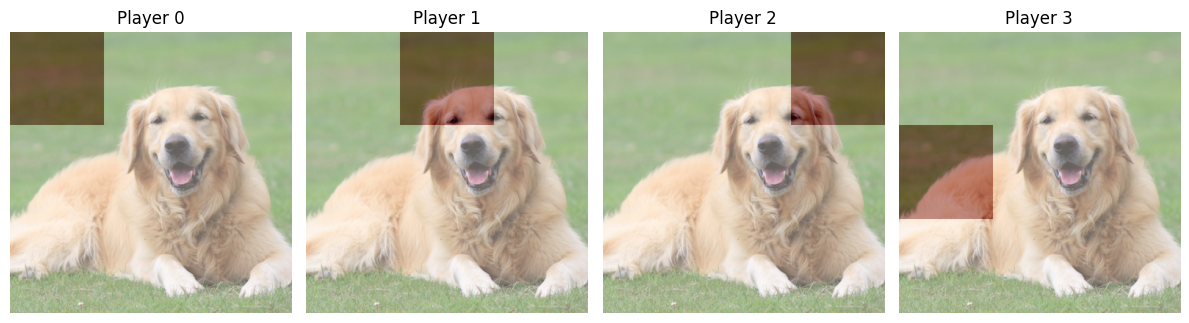

In [36]:
# Cell: Patch mask visualization (proxy in pixel space)
import numpy as np
import matplotlib.pyplot as plt

# Use model config to infer patch grid
image_size = model.config.image_size          # 384 for patch32-384, 224 for patch16-224
patch_size = model.config.patch_size          # 32 or 16
grid_size = image_size // patch_size          # 12 or 14

n_players = strategy.n_players
side = int(np.sqrt(n_players))
block = grid_size // side

# Build player masks on patch grid: (n_players, grid_size, grid_size)
player_masks_grid = np.zeros((n_players, grid_size, grid_size), dtype=bool)
for p in range(n_players):
    y = (p // side) * block
    x = (p % side) * block
    player_masks_grid[p, y : y + block, x : x + block] = True

# Upsample to pixel space for visualization
player_masks_img = np.kron(
    player_masks_grid, np.ones((patch_size, patch_size), dtype=bool)
)

# Resize image to model input size for alignment
image_resized = image.resize((image_size, image_size))

# Show a few example masks
fig, axes = plt.subplots(1, min(4, n_players), figsize=(12, 4))
for i, ax in enumerate(axes):
    ax.imshow(image_resized)
    ax.imshow(player_masks_img[i], alpha=0.4, cmap="Reds")
    ax.set_title(f"Player {i}")
    ax.axis("off")
plt.tight_layout()
plt.show()

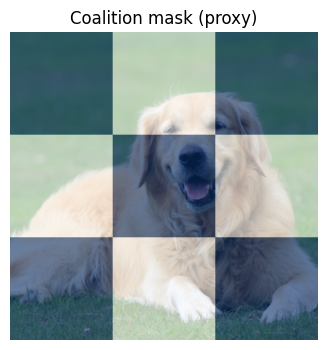

In [39]:
coalition = np.array([True, False, True, False, True, False, True, False, True], dtype=bool)
coalition_mask = player_masks_img[coalition].any(axis=0)

plt.figure(figsize=(4, 4))
plt.imshow(image_resized)
plt.imshow(coalition_mask, alpha=0.6, cmap="Blues")
plt.title("Coalition mask (proxy)")
plt.axis("off")
plt.show()

InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=True, estimation_budget=64,
    n_players=9, baseline_value=7.275957614183426e-11,
    Top 10 interactions:
        (0, 1): 1.347578294825655
        (2, 3): 1.2746834593927228
        (0, 5): 1.2571776636781737
        (3, 7): 0.9685830646444532
        (4, 7): 0.8415703126290139
        (4,): 0.7440194628092707
        (2, 6): -0.866833122139778
        (3, 4): -0.9603397025133755
        (4, 5): -0.9858907220667664
        (0, 3): -1.0191413842026136
)


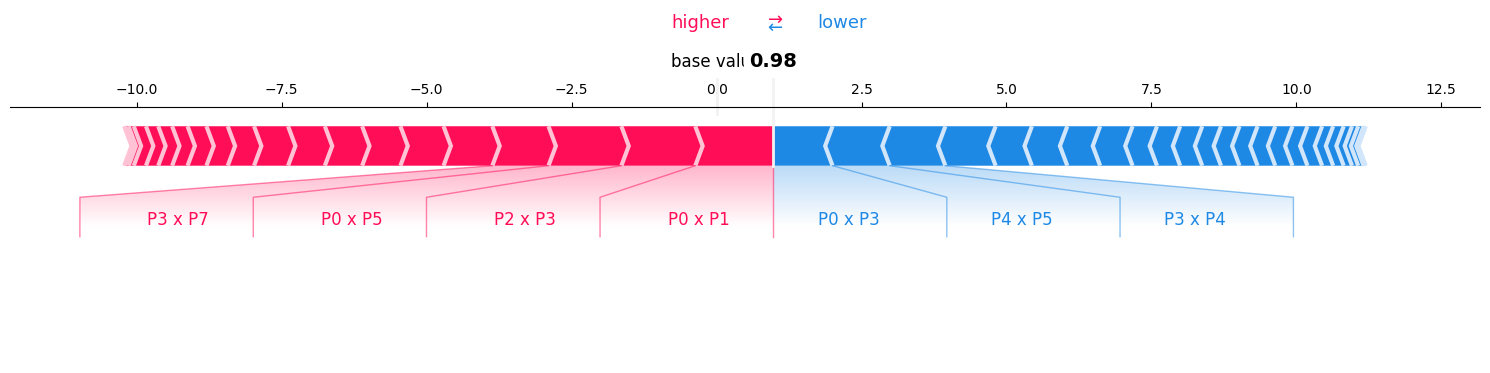

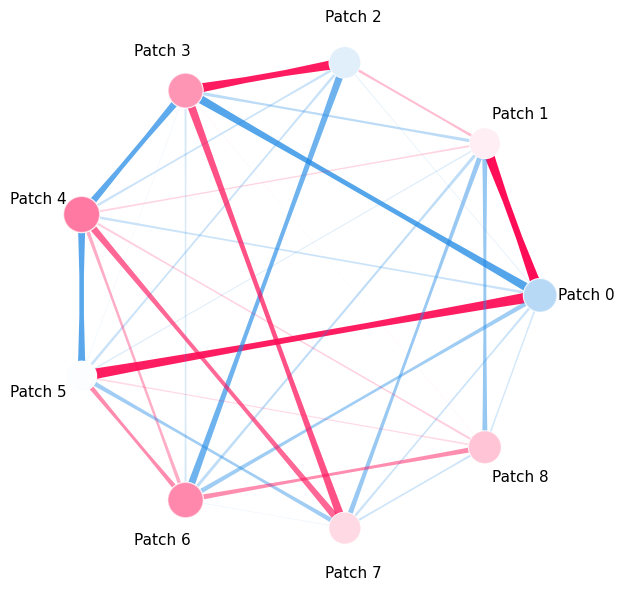

In [35]:
# Cell 5: Approximate SHAP values (ProxySHAP or SHAPIQ)
import shapiq

approx = shapiq.SHAPIQ(n=imputer.n_players, max_order=2, index="k-SII")
interaction_values = approx.approximate(budget=64, game=imputer)

print(interaction_values)
interaction_values.plot_force(feature_names=[f"Patch {i}" for i in range(imputer.n_players)])
interaction_values.plot_network(feature_names=[f"Patch {i}" for i in range(imputer.n_players)])

/tmp/ipykernel_34672/2980420517.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


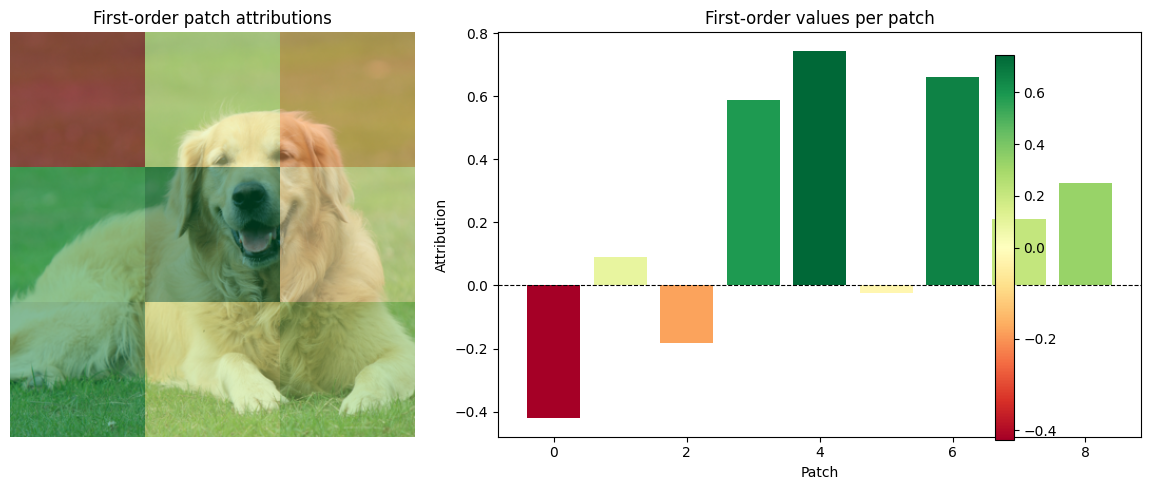

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
# First-order (main effects)
first_order = interaction_values.get_n_order_values(1)

# Rebuild patch grid params (in case this cell runs standalone)
image_size = model.config.image_size
patch_size = model.config.patch_size
grid_size = image_size // patch_size

n_players = strategy.n_players
side = int(np.sqrt(n_players))
block = grid_size // side

# Build heatmap on patch grid
heatmap_grid = np.zeros((grid_size, grid_size), dtype=float)
for p in range(n_players):
    y = (p // side) * block
    x = (p % side) * block
    heatmap_grid[y : y + block, x : x + block] = first_order[p]

# Upsample to pixel space
heatmap_img = np.kron(heatmap_grid, np.ones((patch_size, patch_size)))

# Resize image for alignment
image_resized = image.resize((image_size, image_size))

# Diverging colormap centered at 0
cmap = cm.RdYlGn
norm = mcolors.TwoSlopeNorm(vmin=heatmap_img.min(), vcenter=0, vmax=heatmap_img.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlay heatmap
axes[0].imshow(image_resized)
axes[0].imshow(heatmap_img, alpha=0.5, cmap=cmap, norm=norm)
axes[0].set_title("First-order patch attributions")
axes[0].axis("off")

# Bar plot
bar_colors = [cmap(norm(v)) for v in first_order]
# axes[1].bar(range(n_players), first_order, color=bar_colors)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("Patch")
axes[1].set_ylabel("Attribution")
axes[1].set_title("First-order values per patch")

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.04)

plt.tight_layout()
plt.show()